In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#1. Find and treat all the missing values. Rows or columns with missing values must not be dropped.

df = pd.read_csv('Dataset_Day4.csv')
df.head()

,Prefix,Assignment,Tutorial,Midterm,TakeHome,Final
0,5,57.14,34.09,64.38,51.48,52.50
1,8,95.05,105.49,67.50,99.07,68.33
2,8,83.70,83.17,30.00,63.15,48.89
3,7,81.22,96.06,49.38,105.93,80.56
4,8,91.32,93.64,95.00,107.41,73.89


In [3]:
#Finding the columns with missing values
cols_with_missing = [col for col in df.columns if df[col].isna().sum()>0]
cols_with_missing

['TakeHome', 'Final']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Prefix      99 non-null     int64  
 1   Assignment  99 non-null     float64
 2   Tutorial    99 non-null     float64
 3   Midterm     99 non-null     float64
 4   TakeHome    98 non-null     float64
 5   Final       96 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 4.8 KB


In [5]:
#There are six columns. Here TakeHome and Final have float datatype
#Thus, it must be continuous

numeric_col=[]

for col in df.columns:
    if df[col].dtype.name != 'object':
        numeric_col.append(col)

print(numeric_col)

median_value = df[numeric_col].median()
print(median_value)

MedianImputedData = df.fillna(median_value) #Filling all the missing values with median values

['Prefix', 'Assignment', 'Tutorial', 'Midterm', 'TakeHome', 'Final']
Prefix         8.00
Assignment    89.94
Tutorial      93.10
Midterm       69.38
TakeHome      87.96
Final         66.25
dtype: float64


In [6]:
MedianImputedData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Prefix      99 non-null     int64  
 1   Assignment  99 non-null     float64
 2   Tutorial    99 non-null     float64
 3   Midterm     99 non-null     float64
 4   TakeHome    99 non-null     float64
 5   Final       99 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 4.8 KB


In [7]:
#2. Make an in-depth report on the variables using descriptive statistics and also portray the relationship between each variables using visualizations.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Prefix      99 non-null     int64  
 1   Assignment  99 non-null     float64
 2   Tutorial    99 non-null     float64
 3   Midterm     99 non-null     float64
 4   TakeHome    98 non-null     float64
 5   Final       96 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 4.8 KB


array([[<Axes: title={'center': 'Prefix'}>,
        <Axes: title={'center': 'Assignment'}>],
       [<Axes: title={'center': 'Tutorial'}>,
        <Axes: title={'center': 'Midterm'}>],
       [<Axes: title={'center': 'TakeHome'}>,
        <Axes: title={'center': 'Final'}>]], dtype=object)

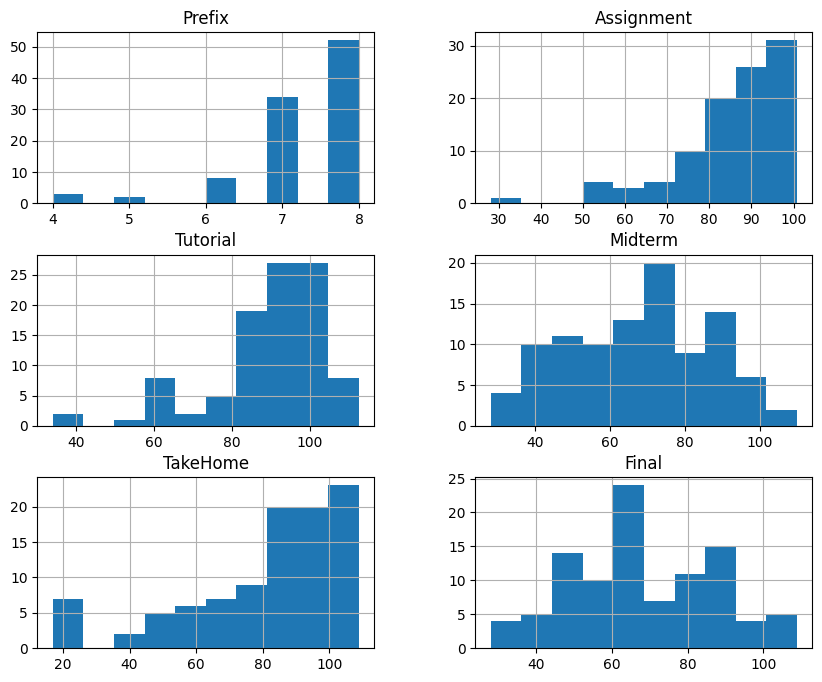

In [11]:
#Histogram
ColumnsToVisualize = ["Prefix", "Assignment", "Tutorial", "Midterm", "TakeHome", "Final"]

MedianImputedData[ColumnsToVisualize].hist(figsize=(10, 8))

Observations:

Most students have scored between 80 and 100 for Assignment.
Most students have scored between 80 and 100 for Tutorial.
Most students have scored between 60 and 80 for Midterm and Final.

<Axes: >

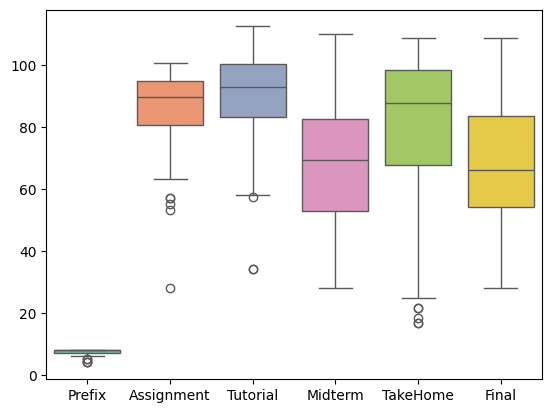

In [12]:
#Boxplot
sns.boxplot(data=MedianImputedData[ColumnsToVisualize],orient="v",palette = "Set2")


Midterms and Finals show high variations
Assignment and Tutorials show lower variations
Assignment, Tutorial and TakeHome has outliers in the lower-end

<Axes: >

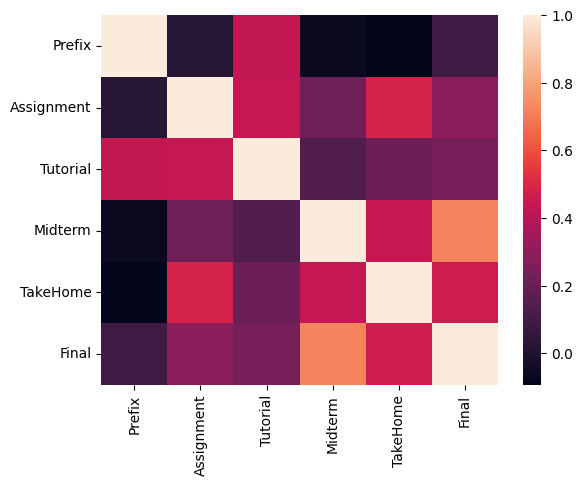

In [13]:
#HeatMap
sns.heatmap(MedianImputedData.select_dtypes(include='number').corr())

Final has a strong positive correlation with Midterm. Thus, we can say that a student's performance in midterm is similar to that in the finals.

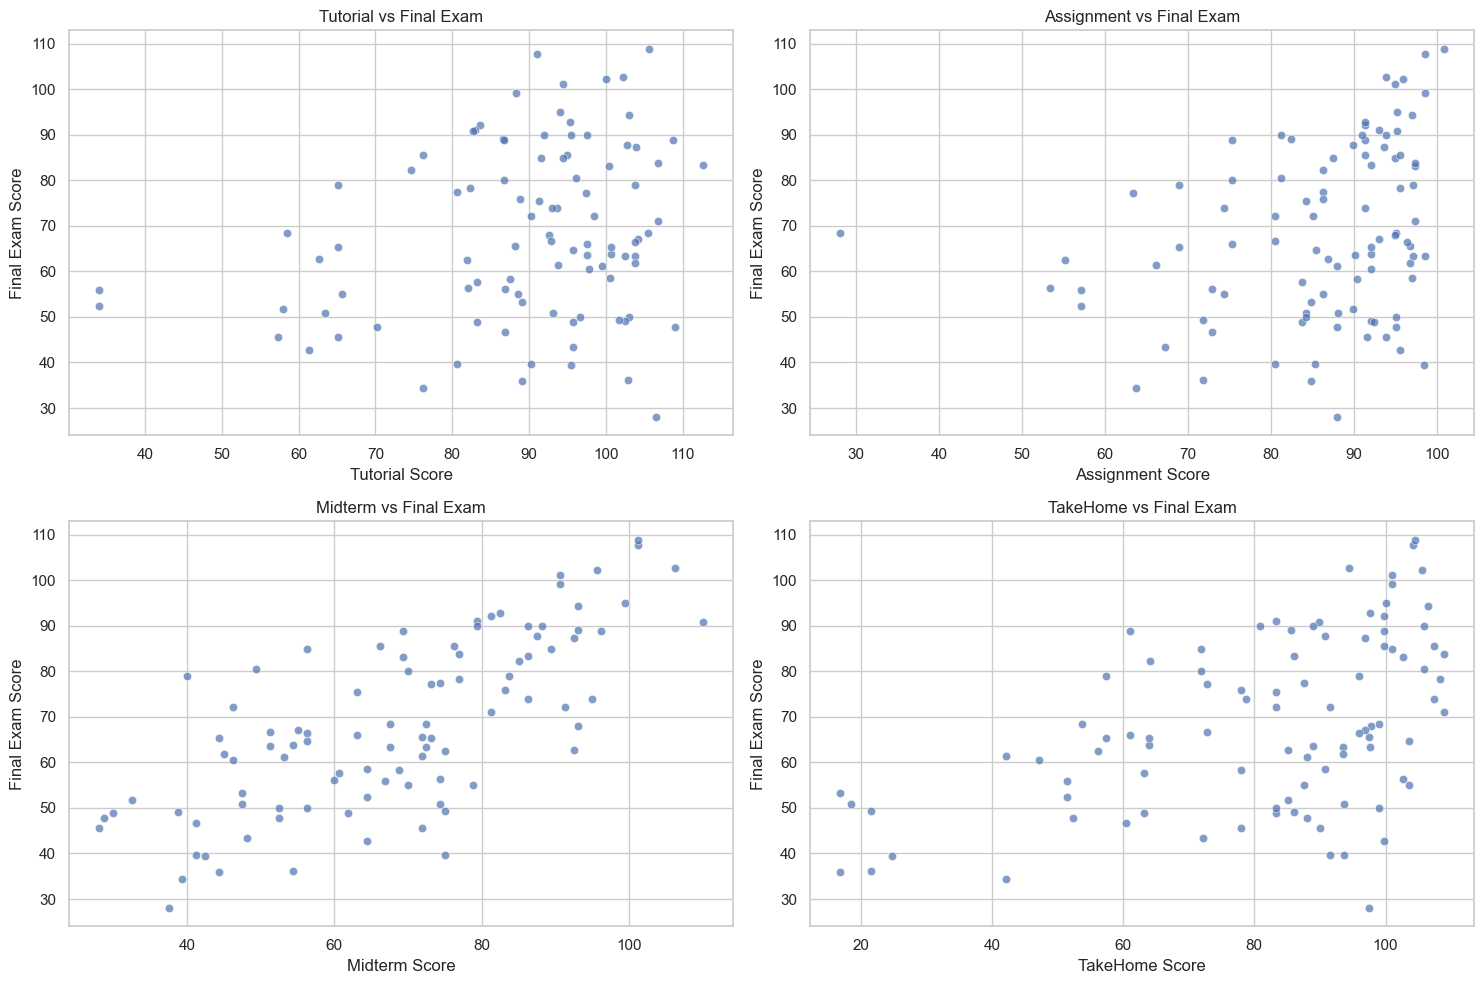

In [15]:
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))

# for creating subplots for the predicters
predictors = ['Tutorial', 'Assignment', 'Midterm', 'TakeHome']

for i, predictor in enumerate(predictors, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(data=df, x=predictor, y='Final', alpha=0.7)
    plt.title(f'{predictor} vs Final Exam')
    plt.xlabel(f'{predictor} Score')
    plt.ylabel('Final Exam Score')
    
plt.tight_layout()
plt.show()

The scatter plot of Midterm vs Final Exam is more linear which suggests that students that who do well on midterm tend to do score well in endterm
